# Introduction

Introduction text / cells go here...

# Data setup

In [1]:
# !uv pip install gdown
# !uv pip install umap-learn

import gdown

In [2]:
model_zip_id = "1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W"
output = "../reference_data/models/"
gdown.download(id=model_zip_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W
From (redirected): https://drive.google.com/uc?id=1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W&confirm=t&uuid=25eb3769-134a-49d3-a4a5-1a1ff85ad72d
To: /Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.53G/1.53G [01:08<00:00, 22.3MB/s]


'../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip'

In [3]:
penncath_hg38_id = "1d1phne1USPa7gkj7LOneyFH9zcGexvHs"
output = "../reference_data/"
gdown.download(id=penncath_hg38_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs
From (redirected): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs&confirm=t&uuid=11480f9c-1e38-4e20-8bfb-268143f0e963
To: /Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/reference_data/penncat_hg38.zip
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143M/143M [00:06<00:00, 20.9MB/s]


'../reference_data/penncat_hg38.zip'

In [4]:
!unzip -o ../reference_data/penncat_hg38.zip -d ../reference_data/

Archive:  ../reference_data/penncat_hg38.zip
  inflating: ../reference_data//penncath_hg38/penncath.csv  
  inflating: ../reference_data//penncath_hg38/penncath.bim  
  inflating: ../reference_data//penncath_hg38/penncath.bed  
  inflating: ../reference_data//penncath_hg38/penncath.fam  


# Prediction

In [1]:
!eirautogppredict --genotype_data_path ../reference_data/penncath_hg38 --packed_experiment_path ../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip --output_folder ../output

14:26:56 - WARNING - eir_auto_gp.predict.prepare_data - Dropping 1 ambiguous (palindromic) SNPs.
14:26:56 - INFO - eir_auto_gp.predict.prepare_data - Matching Stats: Exact=31513, Reversal=15743, StrandFlip=31404, Flip+Rev=15868
14:26:56 - INFO - eir_auto_gp.predict.prepare_data - Applying PLINK pre-filtering (94528/861221 SNPs matched)
14:26:56 - INFO - eir_auto_gp.predict.prepare_data - Created extract list with 94528 unique VAR_IDs from 94528 matched SNPs
14:26:56 - INFO - eir_auto_gp.predict.prepare_data - Running: plink2 --bfile ../reference_data/penncath_hg38/penncath --extract ../output/data/plink_temp_86a9b9d5/extract_list.txt --make-bed --keep-allele-order --out ../output/data/plink_temp_86a9b9d5/filtered
14:26:57 - INFO - eir_auto_gp.predict.prepare_data - PLINK filtering completed successfully
14:26:57 - INFO - eir_auto_gp.predict.prepare_data - PLINK stdout: PLINK v2.0.0-a.6.4 M1 (6 Dec 2024)                 cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christophe

# Analysis

## Imports and setup

In [6]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

In [7]:
def load_trait_csv(path: Path) -> pd.Series:
  df = pd.read_csv(path).set_index("ID")
  trait = path.stem
  prob1 = [c for c in df.columns if c.endswith("Ensemble Prob 1")]
  if prob1:
      s = df[prob1[0]].rename(trait)
      s.attrs["kind"] = "binary"
      return s
  ensemble = [c for c in df.columns if re.fullmatch(rf"{re.escape(trait)} Ensemble", c)]
  if not ensemble:
      raise ValueError(f"No ensemble column found in {path.name}: {list(df.columns)}")
  s = df[ensemble[0]].rename(trait)
  s.attrs["kind"] = "continuous"
  return s

## Loading in the predictions

In [8]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

preds = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {preds.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")
display(preds.head())

labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {labels.shape}")
display(labels.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542770,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.537926,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361750,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.547020,76.31497,6.289234,52.096508,23.333853,37.992416
10005,22.484835,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930590,76.097400,75.78765,6.923183,51.953293,26.081810,37.976200
10007,23.979660,45.518280,87.363410,1.639348,1.566334,1.016251,0.852204,24.755083,9.717244,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.782000,70.52157,6.385489,49.508488,22.894985,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538030,78.507370,78.36777,6.650043,52.501266,23.214048,38.252075


labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


## Downstream analysis

In [9]:
# !uv pip install shap
# !uv pip install xgboost
# !uv pip install lightgbm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectFromModel

from scipy.stats import loguniform, randint, uniform

import shap
import warnings

# Ignore unnecessary warnings for a cleaner output
warnings.filterwarnings("ignore")

Train data shape: (1120, 317)
Test data shape: (281, 317)
Selecting features using Lasso (C=0.03)...
Selected 7 features from 315 original features.

--- Running Model: LogisticRegression ---
  > Analyzing Scenario: Base (Features: 2)
  > Analyzing Scenario: Full (Selected) (Features: 9)
  > Analyzing Scenario: Ablated:Full-CAD (Selected) (Features: 8)
  > Analyzing Scenario: Pure GRS (Selected) (Features: 7)
  > Analyzing Scenario: Full (All GRS) (Features: 317)
  > Analyzing Scenario: Ablated:Full-CAD (All GRS) (Features: 316)
  > Analyzing Scenario: CAD Only (Features: 1)
  > Analyzing Scenario: Base + CAD Only (Features: 3)

--- Running Model: RandomForest ---
  > Analyzing Scenario: Base (Features: 2)
  > Analyzing Scenario: Full (Selected) (Features: 9)
  > Analyzing Scenario: Ablated:Full-CAD (Selected) (Features: 8)
  > Analyzing Scenario: Pure GRS (Selected) (Features: 7)
  > Analyzing Scenario: Full (All GRS) (Features: 317)
  > Analyzing Scenario: Ablated:Full-CAD (All GRS) 

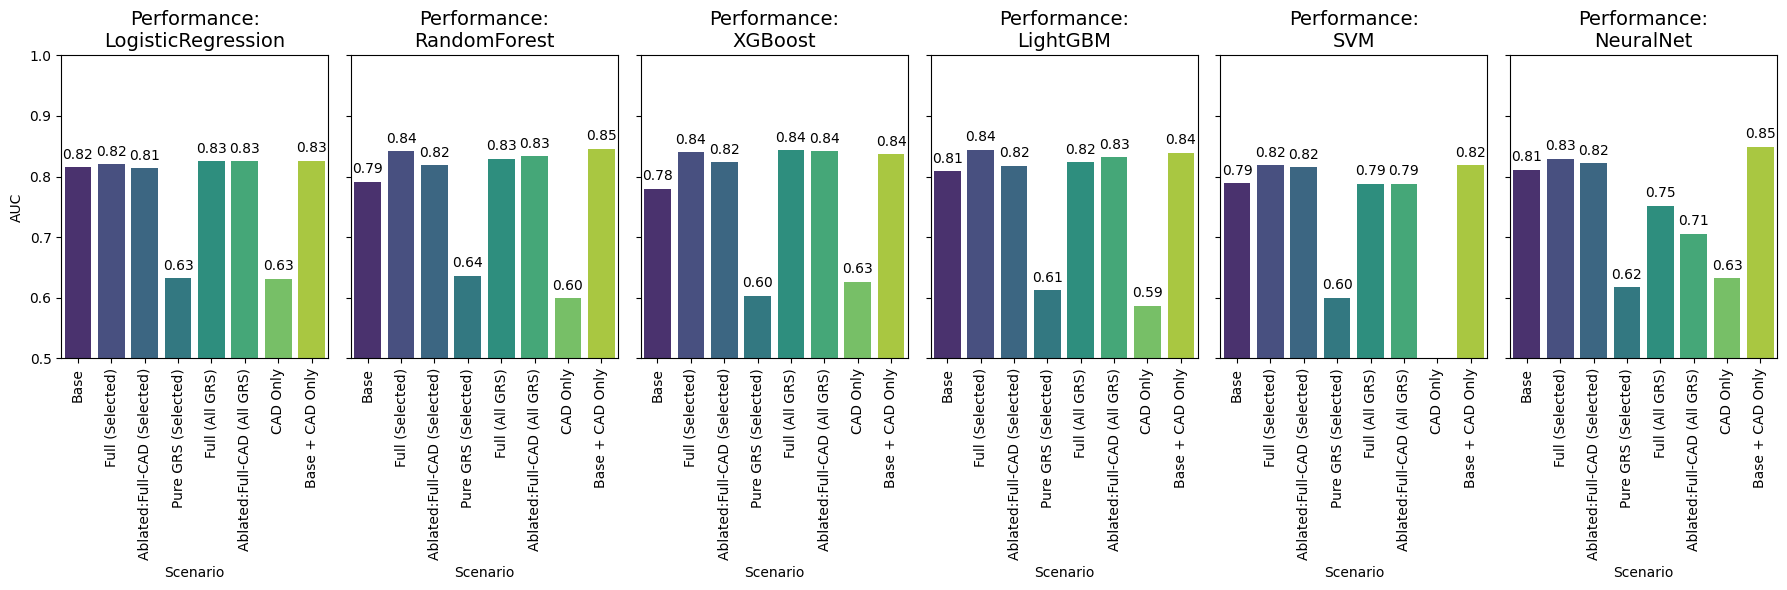

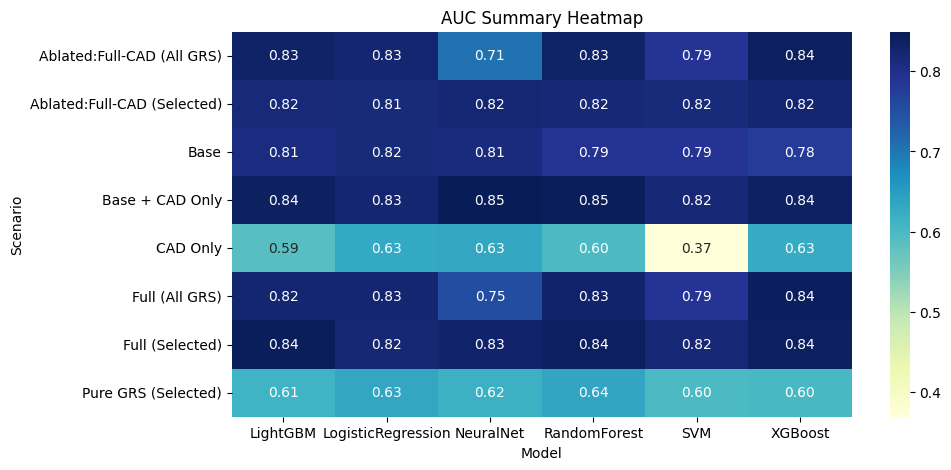

In [10]:
# ==========================================
# 1. Feature Selection (Lasso L1)
# ==========================================
def perform_feature_selection(X_train, y_train, C_val=0.05):
    """
    Selects top features using Lasso (L1) regularization to reduce noise.
    SelectFromModel: Selects important features using Lasso (L1 penalty).
    High C means more features, Low C means fewer features.
    """
    print(f"Selecting features using Lasso (C={C_val})...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Use Logistic Regression with L1 penalty for selection
    selector_model = LogisticRegression(penalty='l1', solver='liblinear', C=C_val, random_state=42)
    selector = SelectFromModel(selector_model)
    selector.fit(X_train_scaled, y_train)
    
    selected_features = X_train.columns[selector.get_support()].tolist()
    print(f"Selected {len(selected_features)} features from {X_train.shape[1]} original features.")
    return selected_features


# ==========================================
# 2. Setup Scenarios
# ==========================================
df = preds.join(labels[['CAD', 'sex', 'age']], how='inner')
df = df.dropna(subset=['CAD'])

# Define Variables
COVARIATES = ['sex', 'age']
CAD_GRS_COL = "I25"  # Actual target GRS name
y = df['CAD'].astype(int)
X = df.drop(columns=['CAD'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train data shape: {X_train_raw.shape}")
print(f"Test data shape: {X_test_raw.shape}")

# Feature Selection execution
grs_cols = [c for c in X_train_raw.columns if c not in COVARIATES]
selected_grs = perform_feature_selection(X_train_raw[grs_cols], y_train, C_val=0.03)

# Define ALL Scenarios
scenarios = {
    "Base": COVARIATES,
    
    # --- Selected Features (Lasso) ---
    "Full (Selected)": COVARIATES + selected_grs,
    "Ablated:Full-CAD (Selected)": COVARIATES + [f for f in selected_grs if f != CAD_GRS_COL],
    "Pure GRS (Selected)": selected_grs,
    
    # --- All Features (No Selection) ---
    "Full (All GRS)": COVARIATES + grs_cols,
    "Ablated:Full-CAD (All GRS)": COVARIATES + [f for f in grs_cols if f != CAD_GRS_COL],
    
    # --- Single Feature ---
    "CAD Only": [CAD_GRS_COL],
    "Base + CAD Only": COVARIATES + [CAD_GRS_COL]
}

# ==========================================
# 3. Training & Evaluation Function
# ==========================================
def evaluate_scenario(model_obj, param_grid, n_iter, scenario_name, feature_list, X_tr, X_te, y_tr, y_te):
    print(f"  > Analyzing Scenario: {scenario_name} (Features: {len(feature_list)})")
    
    X_tr_sub = X_tr[feature_list]
    X_te_sub = X_te[feature_list]
    
    # Hyperparameter Tuning
    search = RandomizedSearchCV(model_obj, param_grid, n_iter=n_iter, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
    #search = RandomizedSearchCV(model_obj, param_grid, n_iter=10, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
    search.fit(X_tr_sub, y_tr)
    best_model = search.best_estimator_
    
    # Calculate AUC
    probs = best_model.predict_proba(X_te_sub)[:, 1]
    auc_score = roc_auc_score(y_te, probs)
    
    return auc_score, best_model
    
# ==========================================
# 4. Model Training Loop
# ==========================================

models = {
    "LogisticRegression": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                solver='saga',
                penalty='elasticnet',
                max_iter=5000,
                random_state=42
            ))
        ]),
        {
            'model__C': loguniform(1e-3, 1e2),
            'model__l1_ratio': uniform(0, 1)
        },
        20 
    ),

    "RandomForest": (
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        {
            'n_estimators': randint(200, 800),
            'max_depth': [5, 10, 15, 20, 30],
            'min_samples_split': randint(2, 15),
            'min_samples_leaf': randint(1, 8),
            'max_features': ['sqrt', 'log2', 0.5]
        },
        30
    ),

    "XGBoost": (
        XGBClassifier(
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        {
            'n_estimators': randint(200, 1000),
            'learning_rate': loguniform(1e-3, 2e-1),
            'max_depth': randint(3, 10),
            'min_child_weight': randint(1, 10),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
            'gamma': uniform(0, 5),
            'reg_alpha': loguniform(1e-3, 10),
            'reg_lambda': loguniform(1e-3, 10)
        },
        50
    ),

    "LightGBM": (
        LGBMClassifier(
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        ),
        {
            'n_estimators': randint(200, 1000),
            'learning_rate': loguniform(1e-3, 2e-1),
            'num_leaves': randint(20, 150),
            'max_depth': [-1, 5, 10, 15],
            'min_child_samples': randint(5, 50),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
            'reg_alpha': loguniform(1e-3, 10),
            'reg_lambda': loguniform(1e-3, 10)
        },
        50
    ),

    "SVM": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC(
                kernel='rbf',
                probability=True,
                random_state=42
            ))
        ]),
        {
            'model__C': loguniform(1e-2, 1e2),
            'model__gamma': loguniform(1e-4, 1)
        },
        40
    ),
    
    "NeuralNet": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                max_iter=2000,
                early_stopping=True,
                random_state=42
            ))
        ]),
        {
            'model__hidden_layer_sizes': [
                (64,),
                (128,),
                (64, 64),
                (128, 64)
            ],
            'model__activation': ['relu', 'tanh'],
            'model__alpha': loguniform(1e-5, 1e-1),
            'model__learning_rate_init': loguniform(1e-4, 1e-2),
            'model__batch_size': [32, 64, 128]
        },
        50
    )
}

results_list = []

for model_name, (model_obj, params, n_iter) in models.items():
    print(f"\n--- Running Model: {model_name} ---")
    for sc_name, feature_list in scenarios.items():
        auc_score, best_model = evaluate_scenario(
            model_obj, params, n_iter, sc_name, feature_list, 
            X_train_raw, X_test_raw, y_train, y_test
        )
        
        if auc_score is not None:
            results_list.append({
                "Model": model_name, 
                "Scenario": sc_name, 
                "AUC": auc_score,
                "Best_Model": best_model,
                "Best_Params": str(best_model.get_params())
            })

# Display clean results DataFrame
res_df = pd.DataFrame(results_list)
print("\n--- Final Results (Top 10) ---")
display_df = res_df.drop(columns=['Best_Params', 'Best_Model']).sort_values(by="AUC", ascending=False).reset_index(drop=True)
print(display_df.head(10))

# ==========================================
# 5. Visualization
# ==========================================
plt.rc('font', family='sans-serif')

unique_models = res_df['Model'].unique()
fig, axes = plt.subplots(1, len(unique_models), figsize=(18, 6), sharey=True)

# Ensure axes is iterable even if only one model is used
if len(unique_models) == 1:
    axes = [axes]

for i, m_name in enumerate(unique_models):
    data_sub = res_df[res_df['Model'] == m_name]
    sns.barplot(data=data_sub, x='Scenario', y='AUC', ax=axes[i], palette='viridis')
    axes[i].set_title(f"Performance:\n{m_name}", fontsize=14)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
    axes[i].set_ylim(0.5, 1.0)
    
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
pivot_df = res_df.pivot(index="Scenario", columns="Model", values="AUC")
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("AUC Summary Heatmap")
plt.show()


Starting Analysis: Best Overall Model
Model: RandomForest | Scenario: Full (Selected)


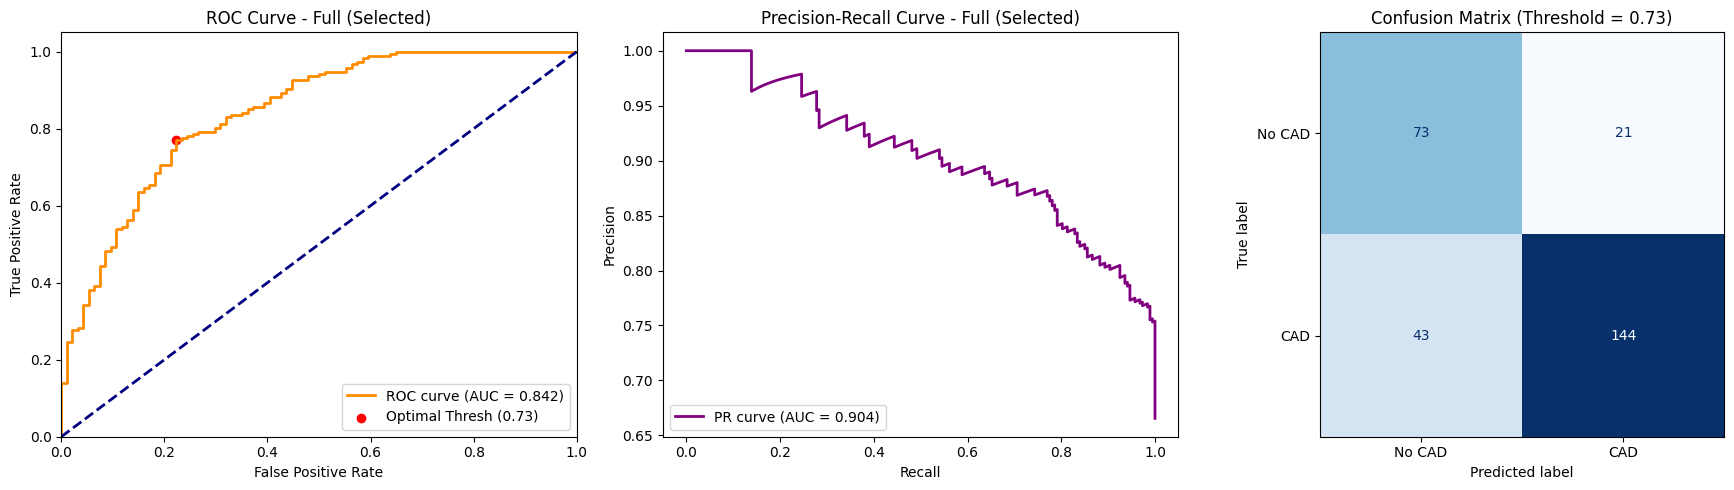


SHAP-based Interpretation (RandomForest / Full (Selected))


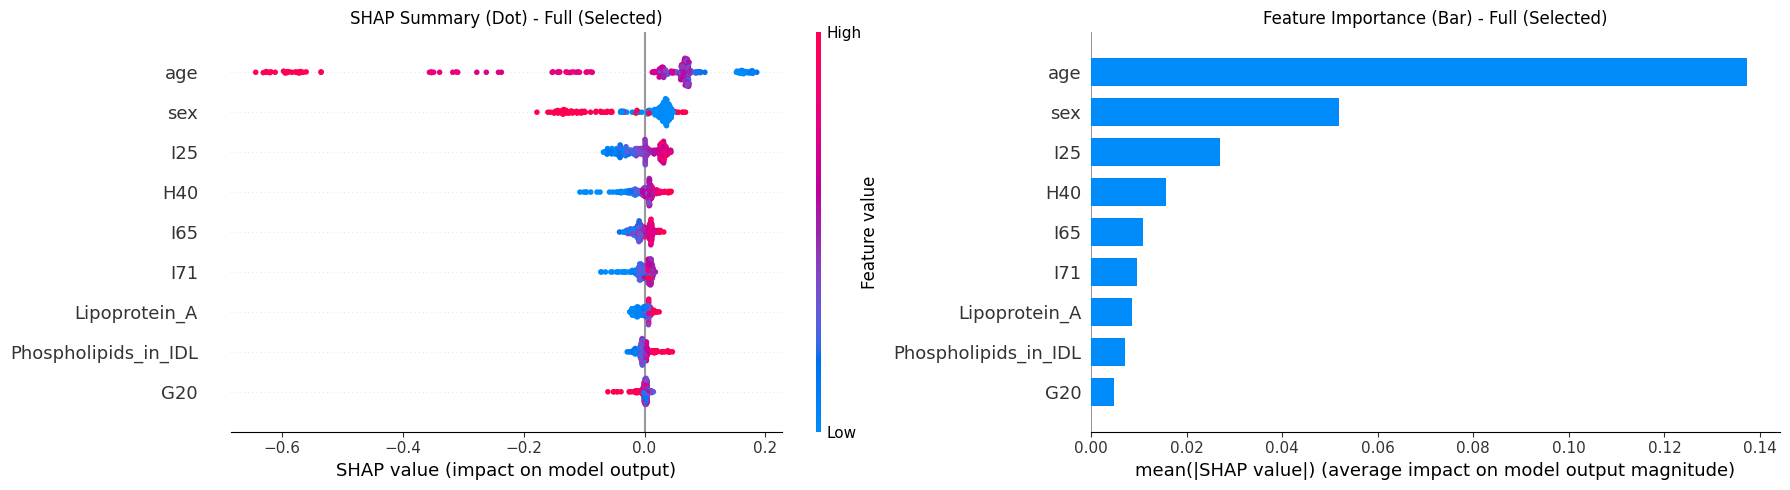

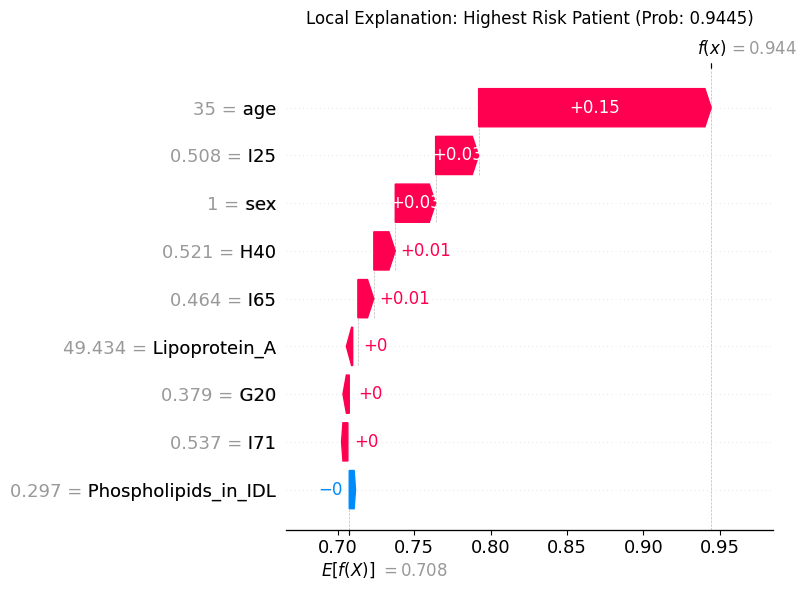


Starting Analysis: Pure GRS Model (Excluding Age & Sex)
Model: RandomForest | Scenario: Pure GRS (Selected)


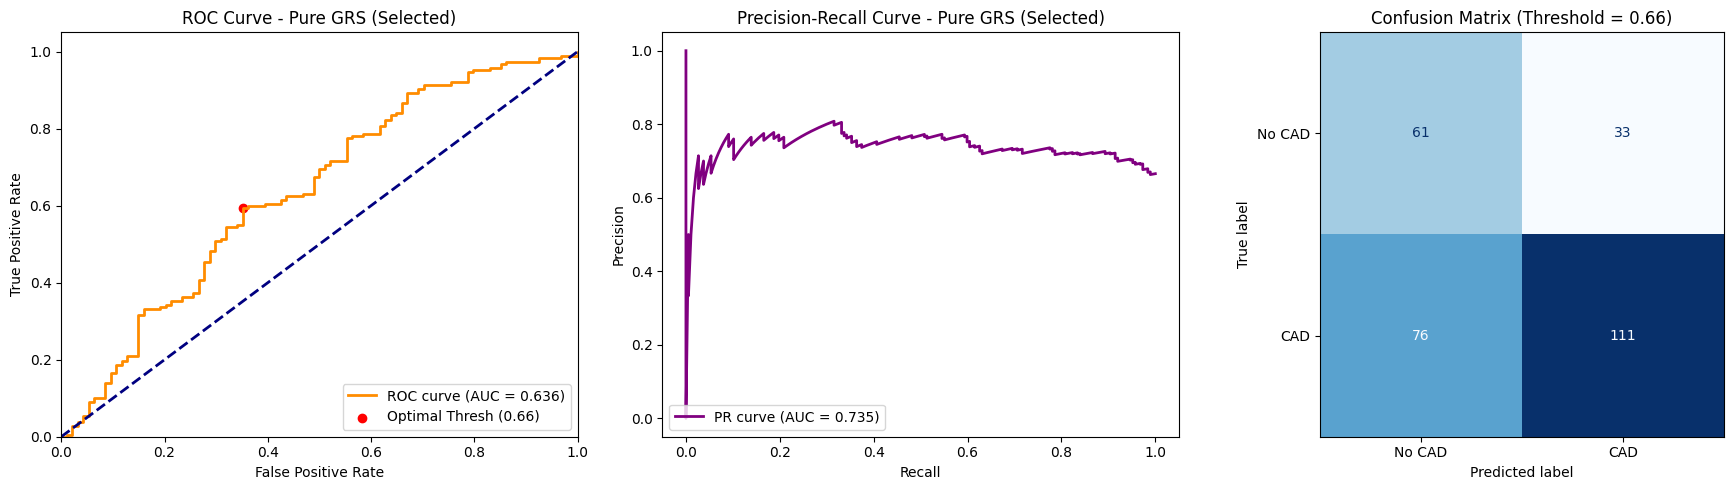


SHAP-based Interpretation (RandomForest / Pure GRS (Selected))


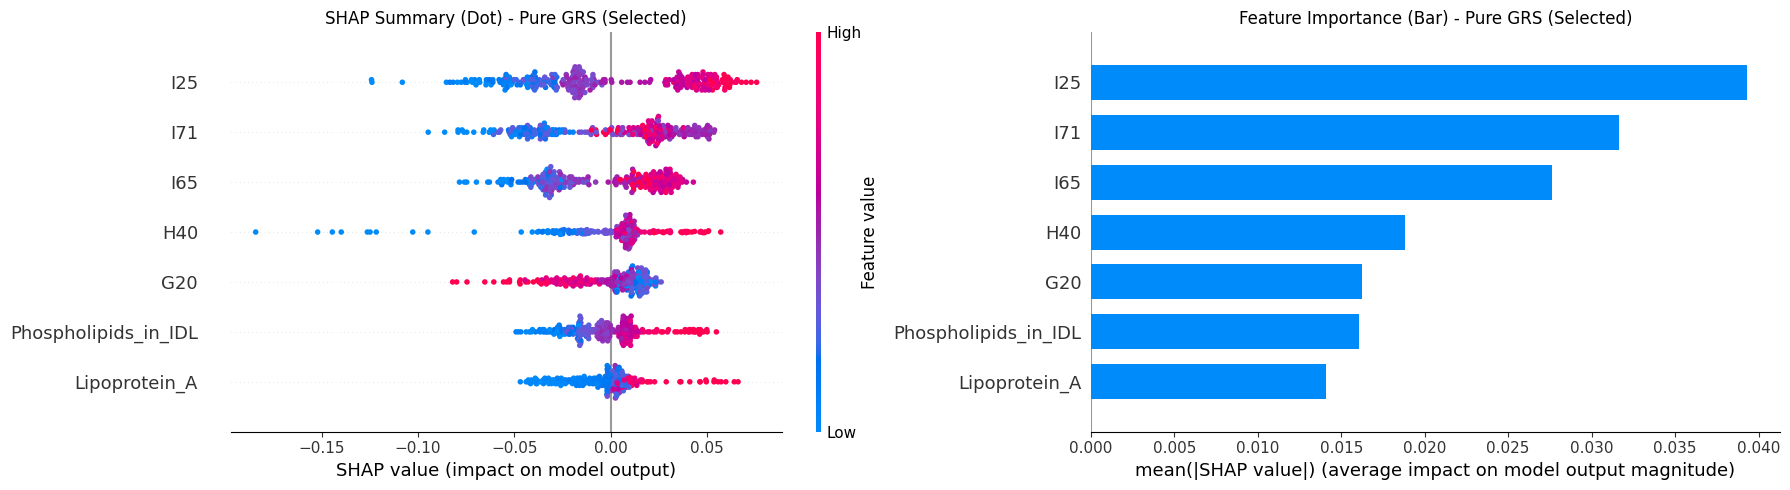

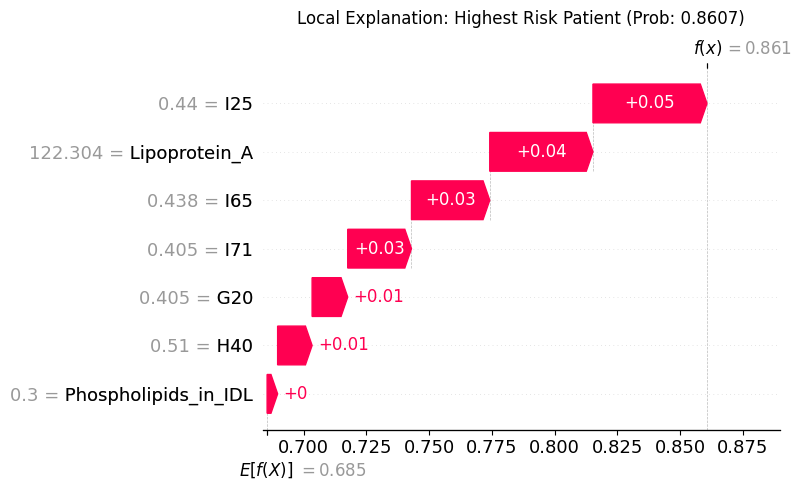

In [14]:
# =====================================================================
# 6. Analysis (Best Model & Pure GRS)
# =====================================================================
# best_idx = res_df['AUC'].idxmax()
# best_model_name = res_df.loc[best_idx, 'Model']
# best_scenario_name = res_df.loc[best_idx, 'Scenario']
best_model_name = 'RandomForest'
best_scenario_name = 'Full (Selected)'

analysis_targets = [
    {"title": "Best Overall Model", "model_name": best_model_name, "scenario": best_scenario_name},
    {"title": "Pure GRS Model (Excluding Age & Sex)", "model_name": best_model_name, "scenario": "Pure GRS (Selected)"}
]

for target in analysis_targets:
    print("\n" + "="*60)
    print(f"Starting Analysis: {target['title']}")
    print(f"Model: {target['model_name']} | Scenario: {target['scenario']}")
    print("="*60)

    # Extract model and features directly from previously trained results
    result_dict = next(item for item in results_list if item["Model"] == target["model_name"] and item["Scenario"] == target["scenario"])
    model_obj = result_dict["Best_Model"]
    features = scenarios[target["scenario"]]

    X_test_target = X_test_raw[features]
    y_prob = model_obj.predict_proba(X_test_target)[:, 1]
    target_auc = roc_auc_score(y_test, y_prob)

    # --- Integrated Performance Graphs ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {target_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'ROC Curve - {target["scenario"]}')
    axes[0].legend(loc="lower right")

    J = tpr - fpr
    best_thresh_idx = np.argmax(J)
    best_thresh = thresholds[best_thresh_idx]
    axes[0].scatter(fpr[best_thresh_idx], tpr[best_thresh_idx], marker='o', color='red', label=f'Optimal Thresh ({best_thresh:.2f})')
    axes[0].legend(loc="lower right")

    # 2) Precision-Recall Curve
    precision, recall, pr_thresh = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Precision-Recall Curve - {target["scenario"]}')
    axes[1].legend(loc="lower left")

    # 3) Confusion Matrix
    y_pred_optimal = (y_prob >= best_thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_optimal)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No CAD", "CAD"])
    disp.plot(cmap=plt.cm.Blues, ax=axes[2], colorbar=False)
    axes[2].set_title(f"Confusion Matrix (Threshold = {best_thresh:.2f})")

    plt.tight_layout()
    plt.show()

    # --- SHAP Analysis ---
    print(f"\nSHAP-based Interpretation ({target['model_name']} / {target['scenario']})")
    
    if hasattr(model_obj, 'named_steps'):
        model_for_shap = model_obj.named_steps['model']
        if 'scaler' in model_obj.named_steps:
            X_test_shap = pd.DataFrame(
                model_obj.named_steps['scaler'].transform(X_test_target), 
                columns=X_test_target.columns
            )
        else:
            X_test_shap = X_test_target
    else:
        model_for_shap = model_obj
        X_test_shap = X_test_target

    explainer = shap.Explainer(model_for_shap, X_test_shap)
    shap_obj = explainer(X_test_shap)
    shap_values = shap_obj.values

    if isinstance(shap_values, list):
        shap_values = shap_values[1]
        shap_obj = shap_obj[..., 1]
    elif len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]
        shap_obj = shap_obj[:, :, 1]

    # Summary Plots
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 2, 1)
    shap.summary_plot(shap_values, X_test_shap, show=False, plot_size=None)
    plt.title(f"SHAP Summary (Dot) - {target['scenario']}")

    plt.subplot(1, 2, 2)
    shap.summary_plot(shap_values, X_test_shap, plot_type="bar", show=False, plot_size=None)
    plt.title(f"Feature Importance (Bar) - {target['scenario']}")

    plt.tight_layout()
    plt.show()

    # Waterfall Plot (Highest Risk Patient)
    highest_risk_idx = np.argmax(y_prob)

    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_obj[highest_risk_idx], max_display=10, show=False)
    plt.title(f"Local Explanation: Highest Risk Patient (Prob: {y_prob[highest_risk_idx]:.4f})", pad=10)
    plt.tight_layout()
    plt.show()